In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_initial = pd.read_csv('C:/Users/Βασίλης/Desktop/lending_case_study_data.csv')  # file inside a folder named "data"
df_initial.head()

,app_date,time_between_start_and_submit_application,website_colour,channel,employer_type,credit_band,is_manual_review,loan_size_gbp,term_months,apr,is_approved,is_taken_up,cac,cost_of_funds,principal_repaid_gbp,interest_repaid_gbp,operating_expenses_gbp,trust_pilot_review
0,2010-01-01 00:31:27.555915608,997,red,Direct,Enterprise,Near Prime,0,0.0,60,0.198279,0,0,10.0,0.0,0.0,0.00,0.0,NaN
1,2010-01-01 00:39:02.014761852,244,red,Direct,Enterprise,Near Prime,0,0.0,24,0.371984,0,0,10.0,0.0,0.0,0.00,0.0,3.0
2,2010-01-01 00:56:40.866416426,371,red,Direct,Enterprise,Near Prime,0,0.0,36,0.286013,1,0,10.0,0.0,0.0,0.00,0.0,NaN
3,2010-01-01 01:12:15.150267644,164,red,Direct,Enterprise,Sub-Prime,1,700.0,24,0.433296,1,1,10.0,112.0,700.0,358.39,2.0,NaN
4,2010-01-01 01:18:38.330197642,494,red,Direct,Public Sector,Sub-Prime,1,0.0,12,0.497090,0,0,10.0,0.0,0.0,0.00,0.0,NaN


# EDA - initial

In [3]:
df_initial.shape         # (rows, columns)

(137333, 18)

In [4]:
df_initial.columns       # List of column names

Index(['app_date', 'time_between_start_and_submit_application',
       'website_colour', 'channel', 'employer_type', 'credit_band',
       'is_manual_review', 'loan_size_gbp', 'term_months', 'apr',
       'is_approved', 'is_taken_up', 'cac', 'cost_of_funds',
       'principal_repaid_gbp', 'interest_repaid_gbp', 'operating_expenses_gbp',
       'trust_pilot_review'],
      dtype='object')

In [5]:
df_initial.info()        # Summary including non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137333 entries, 0 to 137332
Data columns (total 18 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   app_date                                   137333 non-null  object 
 1   time_between_start_and_submit_application  137333 non-null  int64  
 2   website_colour                             137333 non-null  object 
 3   channel                                    137333 non-null  object 
 4   employer_type                              137333 non-null  object 
 5   credit_band                                137333 non-null  object 
 6   is_manual_review                           137333 non-null  int64  
 7   loan_size_gbp                              137333 non-null  float64
 8   term_months                                137333 non-null  int64  
 9   apr                                        137333 non-null  float64
 10  is_appro

In [6]:
df_initial.isnull().sum()           # Number of missing values per column
df_initial.isnull().mean() * 100    # % of missing values per column

app_date                                      0.000000
time_between_start_and_submit_application     0.000000
website_colour                                0.000000
channel                                       0.000000
employer_type                                 0.000000
credit_band                                   0.000000
is_manual_review                              0.000000
loan_size_gbp                                 0.000000
term_months                                   0.000000
apr                                           0.000000
is_approved                                   0.000000
is_taken_up                                   0.000000
cac                                           0.000000
cost_of_funds                                 0.000000
principal_repaid_gbp                          0.000000
interest_repaid_gbp                           0.000000
operating_expenses_gbp                        0.000000
trust_pilot_review                           82.840978
dtype: flo

In [7]:
df_initial.nunique()

app_date                                     137082
time_between_start_and_submit_application       982
website_colour                                    2
channel                                           3
employer_type                                     3
credit_band                                       5
is_manual_review                                  2
loan_size_gbp                                   483
term_months                                       5
apr                                          137329
is_approved                                       2
is_taken_up                                       2
cac                                               4
cost_of_funds                                  1737
principal_repaid_gbp                          25439
interest_repaid_gbp                           45956
operating_expenses_gbp                         7315
trust_pilot_review                                5
dtype: int64

In [8]:
df_initial['credit_band'].unique()

array(['Near Prime', 'Sub-Prime', 'Super Prime', 'Prime', 'Prime Plus'],
      dtype=object)

In [9]:
df_initial['cac'].unique()

array([ 10., 125.,  50.,  75.])

## EDA - metrics/monthly aggregation

In [10]:
df=df_initial.copy()

In [11]:
df['app_date'] = pd.to_datetime(df['app_date'])

In [12]:
df['year'] = df['app_date'].dt.year

In [13]:
df['month'] = df['app_date'].dt.month

In [14]:
#profit calculation 
df['profit']=df['interest_repaid_gbp']-df['cost_of_funds']-df['operating_expenses_gbp']-df['cac']

In [15]:
# Default flag
df["is_default"] = (df["principal_repaid_gbp"] < df["loan_size_gbp"]).astype(int)

# Loss amount (only when default occurs)
df["loss_amount"] = (df["loan_size_gbp"] - df["principal_repaid_gbp"]).clip(lower=0)

In [17]:
# Create channel dummies
channel_dummies = pd.get_dummies(df["channel"], prefix="channel")

# Add them to the dataframe
df = pd.concat([df, channel_dummies], axis=1)

In [18]:
#monthly aggregation
monthly_agg = (
    df.groupby(["year", "month"])
      .agg(
          applications=("app_date", "count"),
          approval_rate=("is_approved", "mean"),
          avg_loan_size=("loan_size_gbp", "mean"),
          avg_apr=("apr", "mean"),
          avg_profit=("profit", "mean"),
          total_profit=("profit", "sum"),

          default_count=("is_default", "sum"),
          total_loss=("loss_amount", "sum"),

          total_loan_amount=("loan_size_gbp", "sum"),
          total_interest=("interest_repaid_gbp", "sum"),
          funded_loans=("is_taken_up", "sum"),
          approved_loans=("is_approved", "sum"),

          channel_direct=("channel_Direct", "sum"),
          channel_aggregator=("channel_Aggregator", "sum"),
          channel_referral=("channel_Referral", "sum")

      )
      .reset_index()
)

In [19]:
monthly_agg["date"] = pd.to_datetime(
    monthly_agg["year"].astype(str) + "-" + monthly_agg["month"].astype(str) + "-01"
)

monthly_agg = monthly_agg.sort_values("date")

In [20]:
monthly_agg["net_revenue"] = (
    monthly_agg["total_profit"] - monthly_agg["total_loss"])

In [21]:
monthly_agg.head()

,year,month,applications,approval_rate,avg_loan_size,avg_apr,avg_profit,total_profit,default_count,total_loss,total_loan_amount,total_interest,funded_loans,approved_loans,channel_direct,channel_aggregator,channel_referral,date,net_revenue
0,2010,1,1512,0.488757,2673.743386,0.318254,567.742884,858427.24,466,364653.01,4042700.0,1314949.50,603,739,1512,0,0,2010-01-01,493774.23
1,2010,2,1449,0.479641,2710.489993,0.312057,565.526404,819447.76,416,365406.99,3927500.0,1269001.57,569,695,1449,0,0,2010-02-01,454040.77
2,2010,3,1709,0.471621,2573.200702,0.322755,563.261855,962614.51,511,387842.29,4397600.0,1483018.03,677,806,1709,0,0,2010-03-01,574772.22
3,2010,4,1739,0.457159,2482.633698,0.316023,529.078321,920067.20,469,427665.50,4317300.0,1427832.90,651,795,1739,0,0,2010-04-01,492401.70
4,2010,5,1782,0.442761,2379.461279,0.327195,501.524102,893715.95,474,342747.92,4240200.0,1387838.88,652,789,1782,0,0,2010-05-01,550968.03


## EDA - 2015 structural break

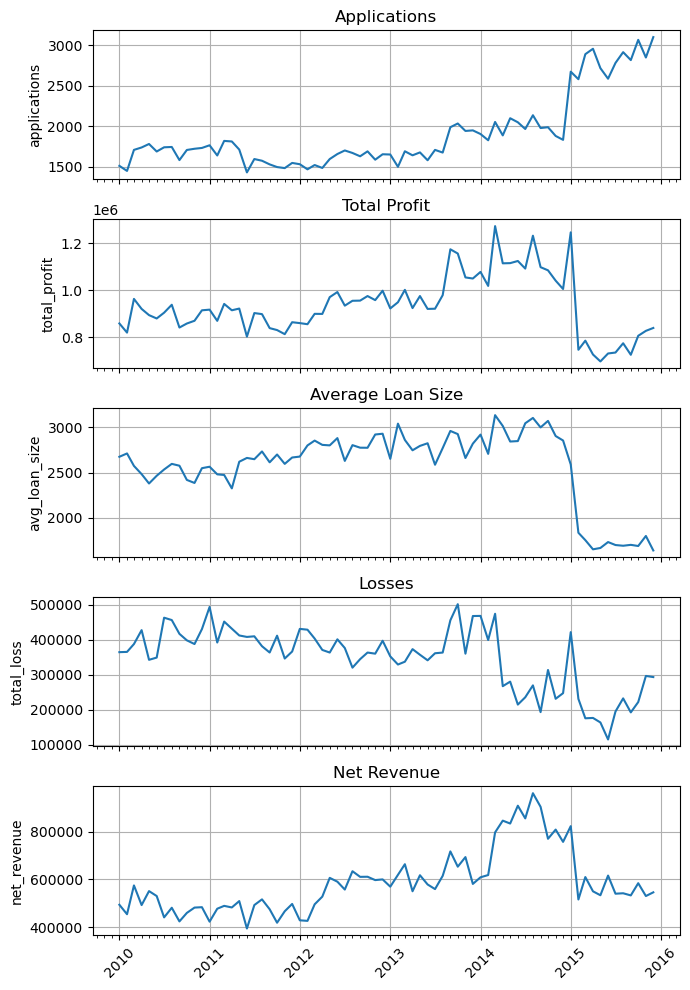

In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(5, 1, figsize=(7,10), sharex=True)

# Flatten axes for easier iteration
axes = axes.flatten()

metrics = [
    "applications",
    "total_profit",
#    "avg_profit",
    "avg_loan_size",
#    "approval_rate",
#    "avg_apr",
#    "default_count",
    "total_loss",
    "net_revenue"
]

titles = [
    "Applications",
    "Total Profit",
#    "Average Profit",
    "Average Loan Size",
#    "Approval Rate",
#    "Average APR",
#    "Defaults",
    "Losses",
    "Net Revenue"
]
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    
for ax, metric, title in zip(axes, metrics, titles):
    ax.plot(monthly_agg["date"], monthly_agg[metric])
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
#plt.show()
plt.savefig('C:/Users/Βασίλης/Desktop/Salary Finance/EDA')

In [23]:
monthly_agg2=monthly_agg[monthly_agg['year']>=2014]

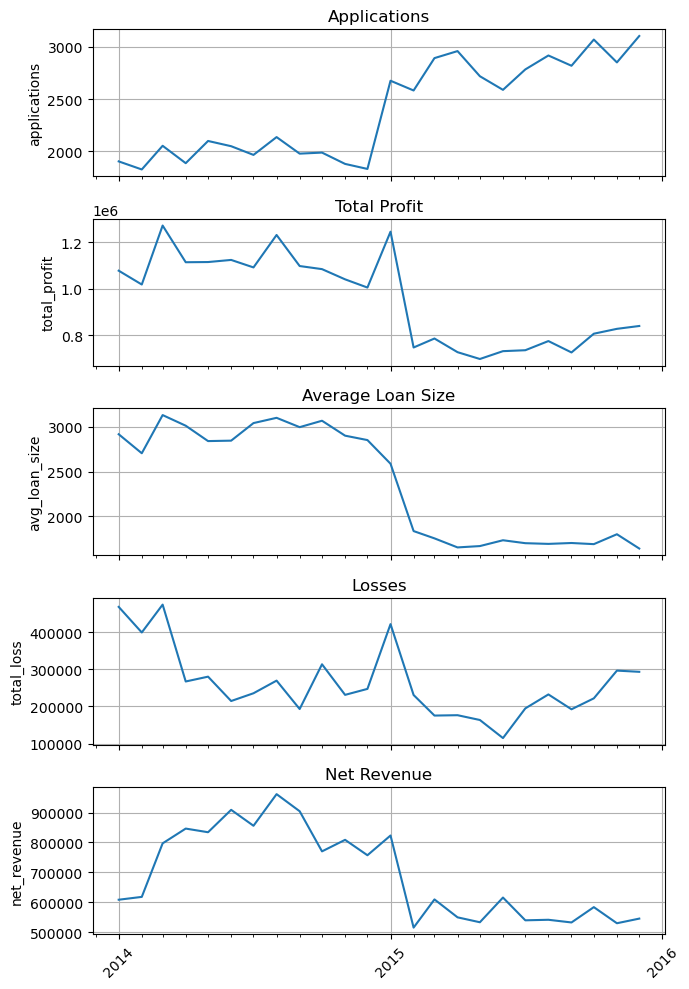

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(5, 1, figsize=(7,10), sharex=True)

# Flatten axes for easier iteration
axes = axes.flatten()

metrics = [
    "applications",
    "total_profit",
#    "avg_profit",
    "avg_loan_size",
#    "approval_rate",
#    "avg_apr",
#    "default_count",
    "total_loss",
    "net_revenue"
]

titles = [
    "Applications",
    "Total Profit",
#    "Average Profit",
    "Average Loan Size",
#    "Approval Rate",
#    "Average APR",
#    "Defaults",
    "Losses",
    "Net Revenue"
]
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    
for ax, metric, title in zip(axes, metrics, titles):
    ax.plot(monthly_agg2["date"], monthly_agg2[metric])
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#plt.savefig('C:/Users/Βασίλης/Desktop/Salary Finance/EDA')

In [25]:
#yearly aggregation
yearly_agg = (
    df.groupby(["year"])
      .agg(
          applications=("app_date", "count"),
          avg_loan_size=("loan_size_gbp", "mean"),
          total_profit=("profit", "sum"),
          total_loss=("loss_amount", "sum")

      )
      .reset_index()
)

In [26]:
yearly_agg["net_revenue"] = (
    yearly_agg["total_profit"] - yearly_agg["total_loss"])

In [27]:
yearly_agg=yearly_agg[yearly_agg['year']>=2014]

In [28]:
yearly_agg.head()

,year,applications,avg_loan_size,total_profit,total_loss,net_revenue
4,2014,23611,2954.974376,13267131.9,3594923.72,9672208.18
5,2015,33949,1783.565790,9637898.0,2713846.91,6924051.09


In [29]:
#yearly percentage change 
cols = yearly_agg.columns.drop('year')
yearly_agg[cols + '_change'] = yearly_agg[cols].pct_change()

In [30]:
yearly_agg.head()

,year,applications,avg_loan_size,total_profit,total_loss,net_revenue,applications_change,avg_loan_size_change,total_profit_change,total_loss_change,net_revenue_change
4,2014,23611,2954.974376,13267131.9,3594923.72,9672208.18,NaN,NaN,NaN,NaN,NaN
5,2015,33949,1783.565790,9637898.0,2713846.91,6924051.09,0.437847,-0.396419,-0.273551,-0.245089,-0.284129


## Q1 2015: Launched on a second aggregator website 

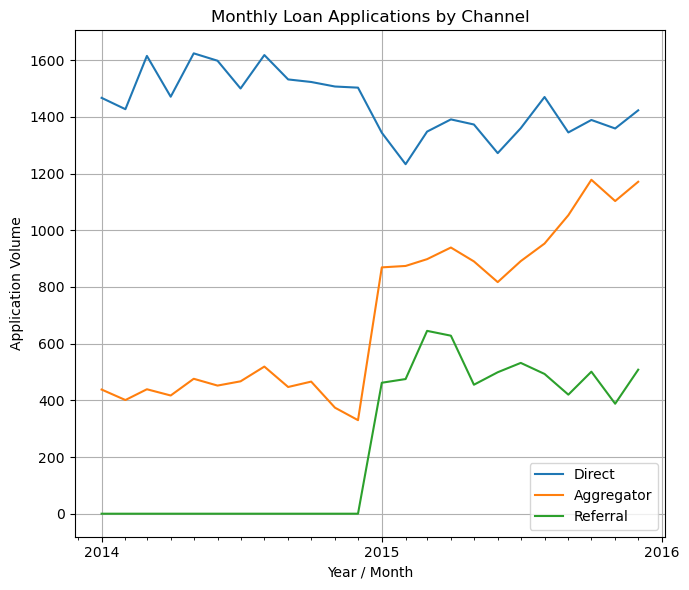

In [31]:
#Monthly Loan Applications by Channel 2014-2015

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(7,6))

channel_cols = [
    "channel_direct",
    "channel_aggregator",
    "channel_referral"
]

labels = {
    "channel_direct": "Direct",
    "channel_aggregator": "Aggregator",
    "channel_referral": "Referral"
}

for col in channel_cols:
    ax.plot(monthly_agg2["date"], monthly_agg2[col], label=labels[col])

# Major ticks = years
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Minor ticks = months
ax.xaxis.set_minor_locator(mdates.MonthLocator())

ax.set_xlabel("Year / Month")
ax.set_ylabel("Application Volume")
ax.set_title("Monthly Loan Applications by Channel")

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()
#plt.savefig('C:/Users/Βασίλης/Desktop/Salary Finance/apps')

In [32]:
#aggregation of fubded loans by chabbel and credit band
channel_credit_mix = (
    df[(df["is_taken_up"] == 1) & (df["year"] >= 2014)]
    .groupby(["year", "channel", "credit_band"])
    .agg(
        loans=("loan_size_gbp", "count")
    )
    .reset_index()
)

In [33]:
direct_data = channel_credit_mix[channel_credit_mix["channel"] == "Direct"]
aggregator_data = channel_credit_mix[channel_credit_mix["channel"] == "Aggregator"]

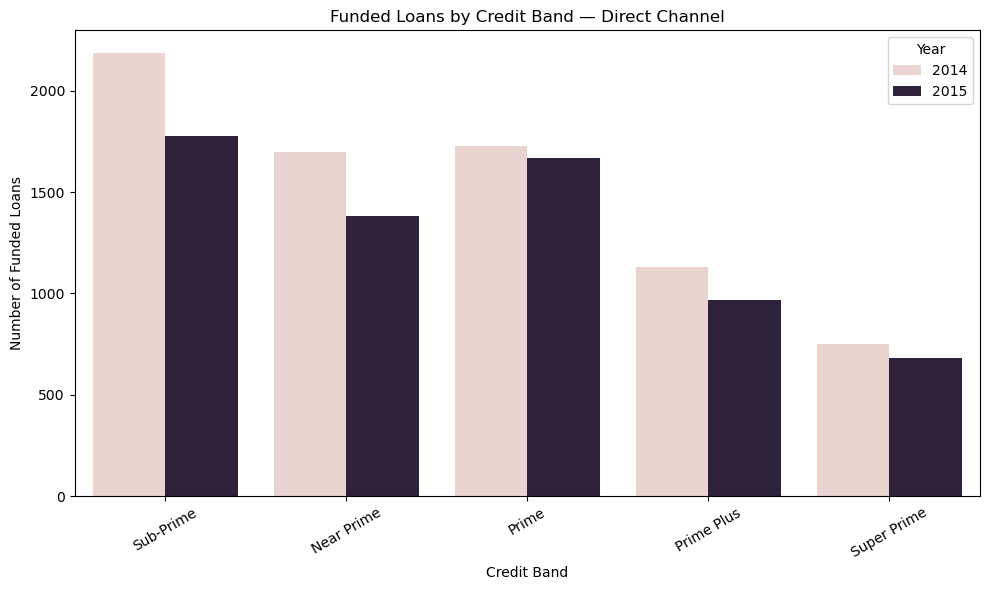

In [34]:
# Funded Loans by Credit Band — Direct Channel

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

band_order = [
    "Sub-Prime",
    "Near Prime",
    "Prime",
    "Prime Plus",
    "Super Prime"
]

sns.barplot(
    data=direct_data,
    x="credit_band",
    y="loans",
    hue="year",
    order=band_order
)

plt.title("Funded Loans by Credit Band — Direct Channel")
plt.xlabel("Credit Band")
plt.ylabel("Number of Funded Loans")
plt.xticks(rotation=30)

plt.legend(title="Year")
plt.tight_layout()
plt.show()
#plt.savefig('C:/Users/Βασίλης/Desktop/Salary Finance/funded_loans_direct')

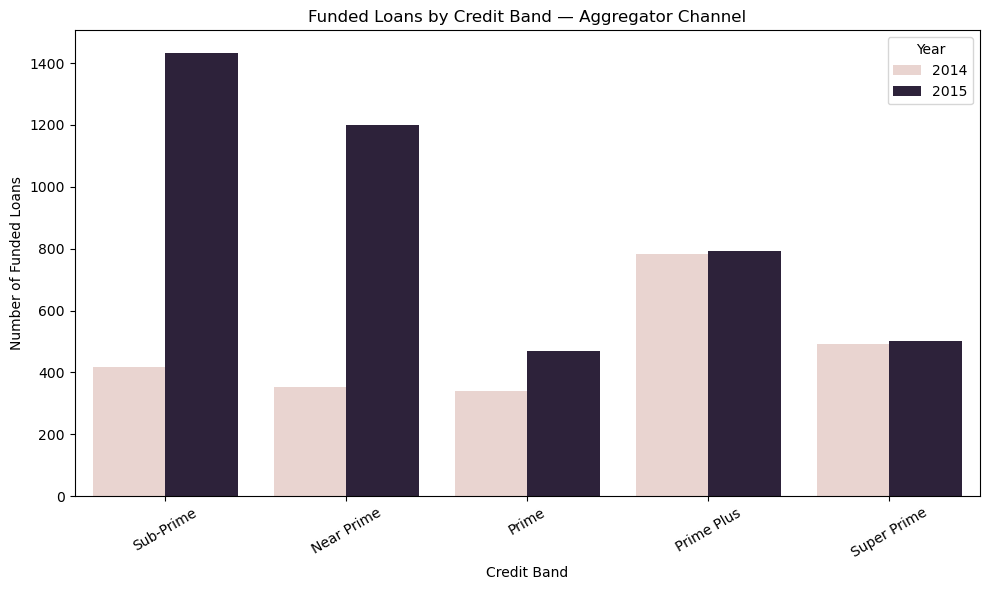

In [35]:
# Funded Loans by Credit Band — Aggregator Channel

plt.figure(figsize=(10,6))

band_order = [
    "Sub-Prime",
    "Near Prime",
    "Prime",
    "Prime Plus",
    "Super Prime"
]

sns.barplot(
    data=aggregator_data,
    x="credit_band",
    y="loans",
    hue="year",
    order=band_order
)

plt.title("Funded Loans by Credit Band — Aggregator Channel")
plt.xlabel("Credit Band")
plt.ylabel("Number of Funded Loans")
plt.xticks(rotation=30)

plt.legend(title="Year")
plt.tight_layout()
plt.show()
#plt.savefig('C:/Users/Βασίλης/Desktop/Salary Finance/funded_loans_agg')

In [36]:
#aggregation by credit band

credit_mix2 = (
    df[ (df["is_taken_up"] == 1) & (df["year"] >= 2014)]
    .groupby(["year", "credit_band"])
    .agg(
        loans=("loan_size_gbp", "count")
    )
    .reset_index()
)

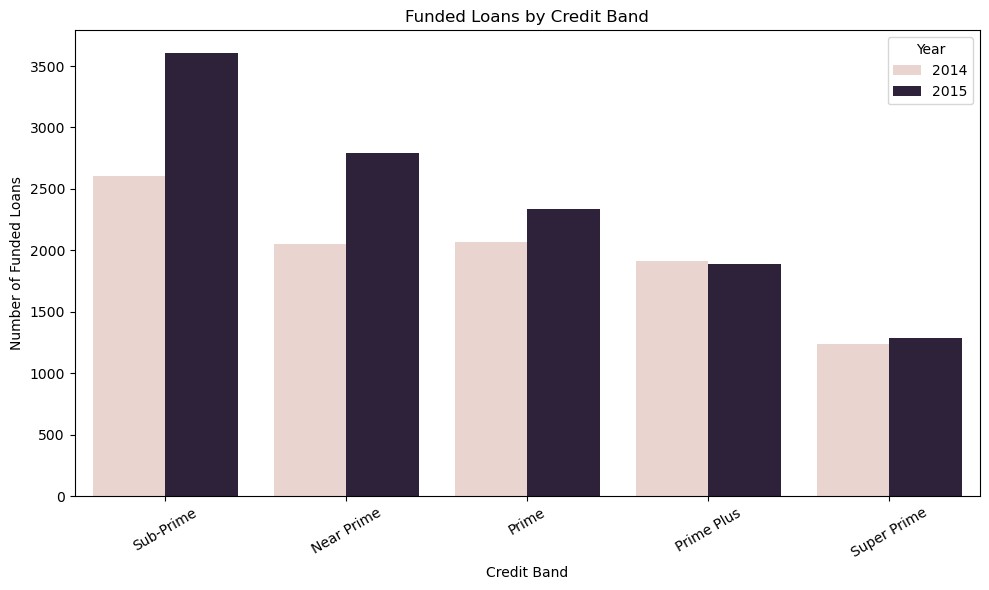

In [37]:
# Funded Loans by Credit Band — Total 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

band_order = [
    "Sub-Prime",
    "Near Prime",
    "Prime",
    "Prime Plus",
    "Super Prime"
]

sns.barplot(
    data=credit_mix2,
    x="credit_band",
    y="loans",
    hue="year",
    order=band_order
)

plt.title("Funded Loans by Credit Band")
plt.xlabel("Credit Band")
plt.ylabel("Number of Funded Loans")
plt.xticks(rotation=30)

plt.legend(title="Year")
plt.tight_layout()
plt.show()

In [38]:
df_2014 = df[df["year"] >= 2014]

In [39]:
channel_agg = (
    df_2014#[df_2015["is_taken_up"] == 1]   # only funded loans
      .groupby(["channel","year"])
      .agg(
          applications=("app_date","count"),
          funded_loans=("is_taken_up","sum"),
          avg_loan_size=("loan_size_gbp","mean"),
          avg_profit=("profit","mean"),
          total_profit=("profit","sum"),
          avg_cac=("cac","mean"),
          total_cac=("cac","sum"),
          default_rate=("is_default","mean"),
          total_loss=("loss_amount","sum")
      )
      .reset_index()
)

In [40]:
#impact of channel mix shift in core metrics
channel_agg.head()

,channel,year,applications,funded_loans,avg_loan_size,avg_profit,total_profit,avg_cac,total_cac,default_rate,total_loss
0,Aggregator,2014,5226,2384,3837.849215,607.344983,3173984.88,125.000000,653250.0,0.110027,822690.67
1,Aggregator,2015,11636,4398,1867.892747,215.675587,2509601.13,107.949467,1256100.0,0.155380,1341601.77
2,Direct,2014,18385,7494,2704.014142,548.988144,10093147.02,10.000000,183850.0,0.143432,2772233.05
3,Direct,2015,16307,6477,2149.438891,416.719612,6795446.72,10.000000,163070.0,0.116637,980909.84
4,Referral,2015,6006,1029,626.802364,55.419605,332850.15,50.000000,300300.0,0.065601,391335.30


## Q1 2015: Implemented strict credit policy tightening, placing maximum loan size caps on low quality customers. 

In [41]:
credit_policy = (
    df[(df["is_taken_up"] == 1) & (df["year"] >= 2014)]
    .groupby(["year","credit_band"])
    .agg(
        loans=("loan_size_gbp","count"),
        total_loan_size=("loan_size_gbp","sum"),
        avg_loan_size=("loan_size_gbp","mean"),
        default_rate=("is_default","mean"),
        total_loss=("loss_amount","sum"),
        avg_profit=("profit","mean"),
        total_profit=("profit","sum")
    )
    .reset_index()
)

In [42]:
credit_policy['loss_rate']=credit_policy['total_loss']/credit_policy['total_loan_size']

In [43]:
credit_policy.head(10)

,year,credit_band,loans,total_loan_size,avg_loan_size,default_rate,total_loss,avg_profit,total_profit,loss_rate
0,2014,Near Prime,2051,10281200.0,5012.774256,0.547050,1509122.94,975.453111,2000654.33,0.146785
1,2014,Prime,2068,16082400.0,7776.789168,0.107834,305999.57,2012.863515,4162601.75,0.019027
2,2014,Prime Plus,1914,19296900.0,10081.974922,0.072100,263026.61,1932.326176,3698472.30,0.013631
3,2014,Sub-Prime,2604,8215200.0,3154.838710,0.649002,1391283.13,590.157339,1536769.71,0.169355
4,2014,Super Prime,1241,15894200.0,12807.574537,0.031426,125491.47,1879.769388,2332793.81,0.007895
5,2015,Near Prime,2790,5819075.0,2085.689964,0.479570,727470.03,276.766953,772179.80,0.125015
6,2015,Prime,2333,17918200.0,7680.325761,0.114874,572894.73,1944.098556,4535581.93,0.031973
7,2015,Prime Plus,1886,18214825.0,9657.913574,0.106575,550122.62,1854.411702,3497420.47,0.030202
8,2015,Sub-Prime,3610,3496825.0,968.649584,0.607756,547156.50,-31.258404,-112842.84,0.156472
9,2015,Super Prime,1285,15101350.0,11752.023346,0.080156,316203.03,1614.325790,2074408.64,0.020939


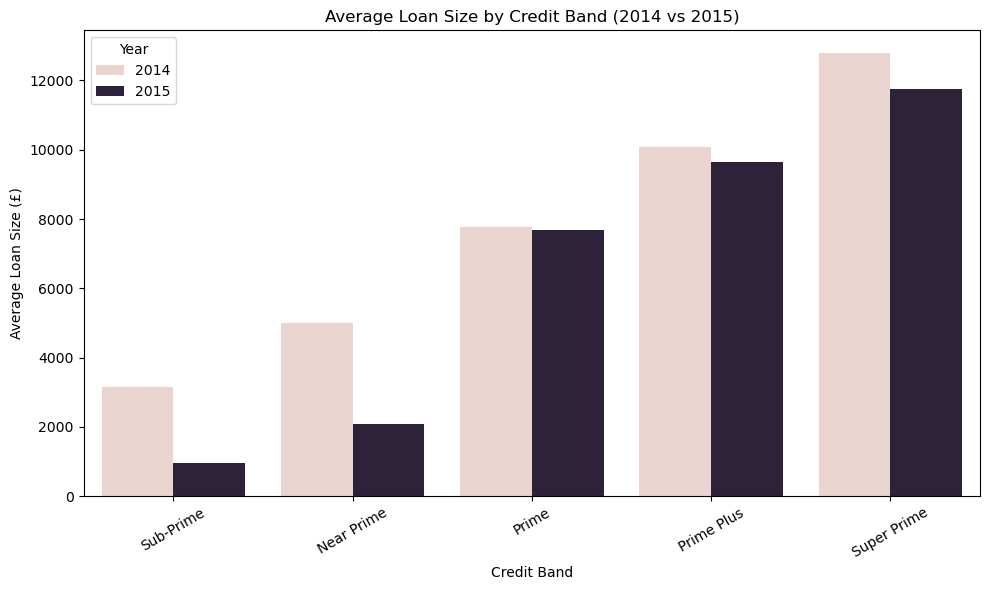

In [44]:


plt.figure(figsize=(10,6))

band_order = [
    "Sub-Prime",
    "Near Prime",
    "Prime",
    "Prime Plus",
    "Super Prime"
]
sns.barplot(
    data=credit_policy,
    x="credit_band",
    y="avg_loan_size",
    hue="year",
    order=band_order
)

plt.title("Average Loan Size by Credit Band (2014 vs 2015)")
plt.xlabel("Credit Band")
plt.ylabel("Average Loan Size (£)")
plt.legend(title="Year")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()
#plt.savefig('C:/Users/Βασίλης/Desktop/Salary Finance/avg_loan_size')

In [45]:
#Aggregation of funded loans by year, month and credit band
monthly_credit = (
    df[(df["is_taken_up"] == 1)&(df["year"] >= 2014)]
    .groupby(["year", "month", "credit_band"])
    .agg(
        avg_loan_size=("loan_size_gbp", "mean"),
        total_profit=("profit", "sum"),
        avg_profit=("profit","mean"),
        total_loss=("loss_amount", "sum")
    )
    .reset_index()
)

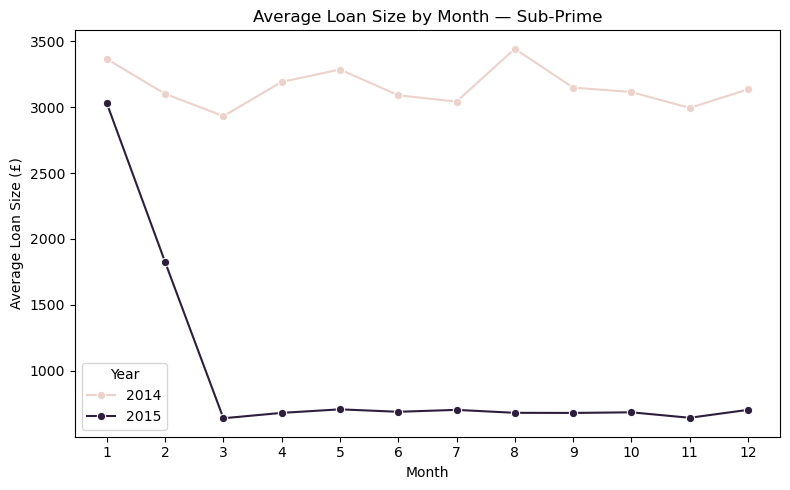

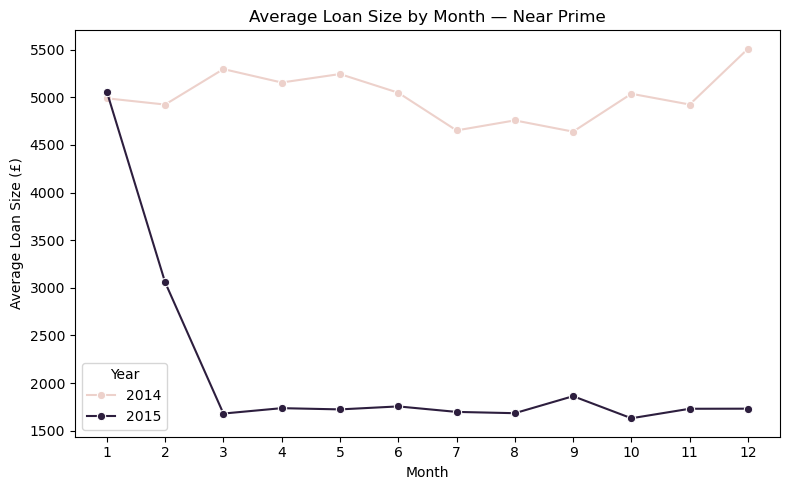

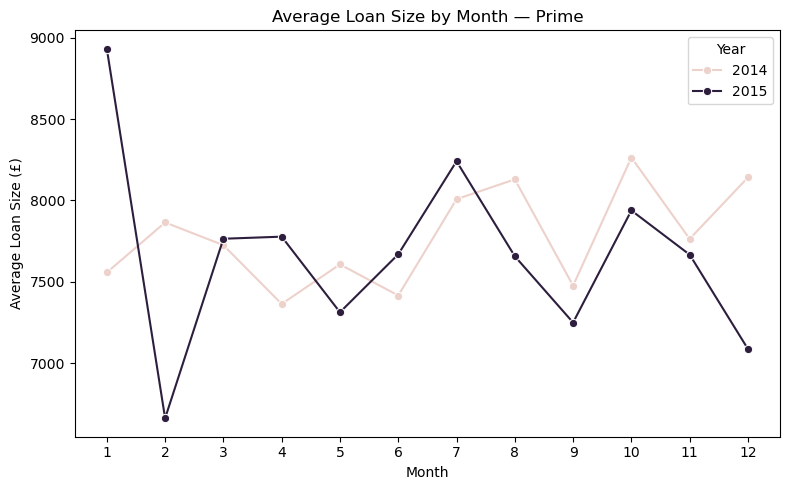

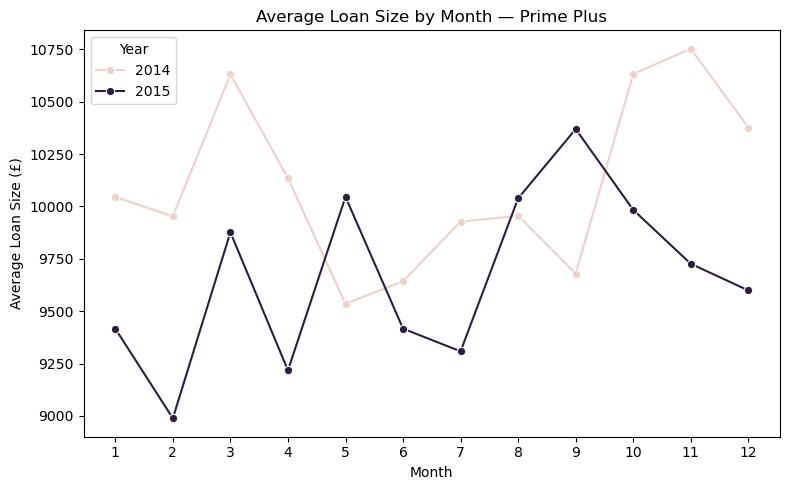

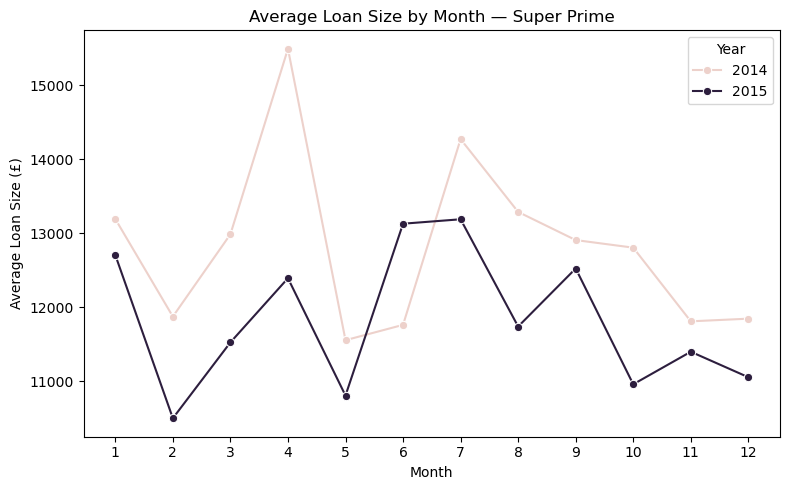

In [46]:
#Average Loan Size by Credit Band


credit_bands = [
    "Sub-Prime",
    "Near Prime",
    "Prime",
    "Prime Plus",
    "Super Prime"
]


for band in credit_bands:
    
    band_data = monthly_credit[monthly_credit["credit_band"] == band]

    plt.figure(figsize=(8,5))

    sns.lineplot(
        data=band_data,
        x="month",
        y="avg_loan_size",
        hue="year",
        marker="o"
    )

    plt.title(f"Average Loan Size by Month — {band}")
    plt.xlabel("Month")
    plt.ylabel("Average Loan Size (£)")
    plt.xticks(range(1,13))
    plt.legend(title="Year")

    plt.tight_layout()
    plt.show()
    #plt.savefig('C:/Users/Βασίλης/Desktop/Salary Finance/avg_loan_size_caps')

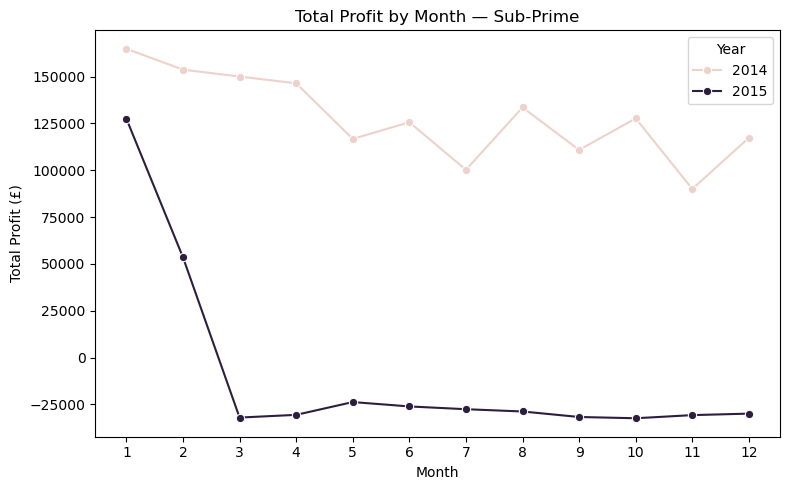

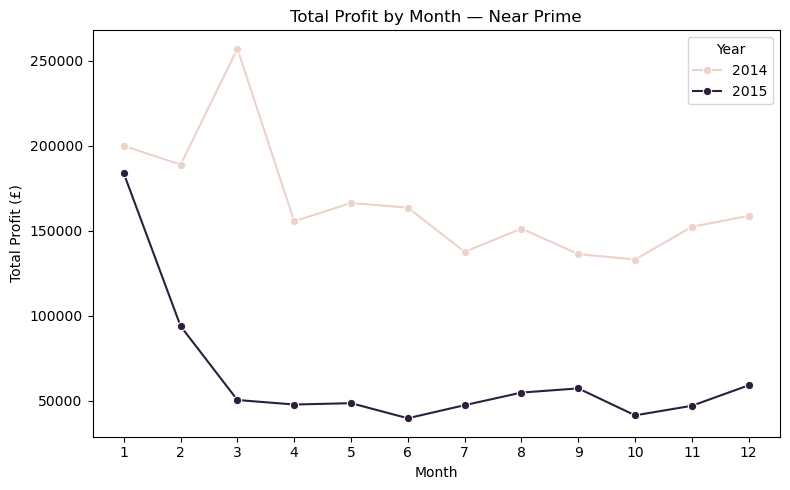

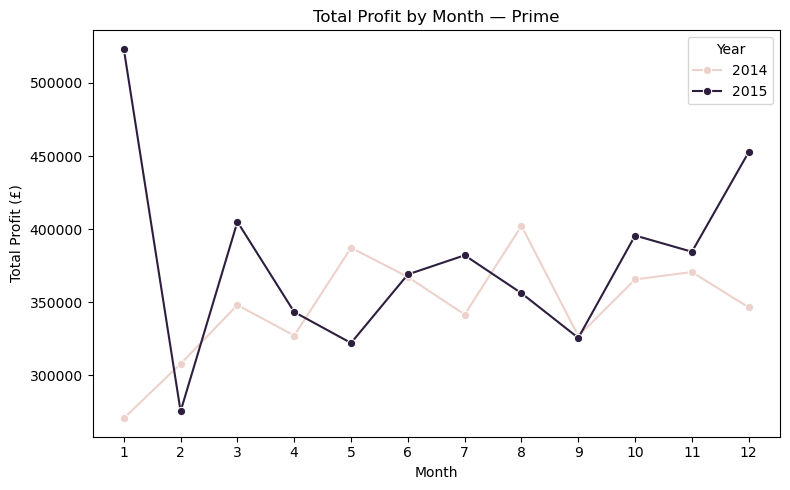

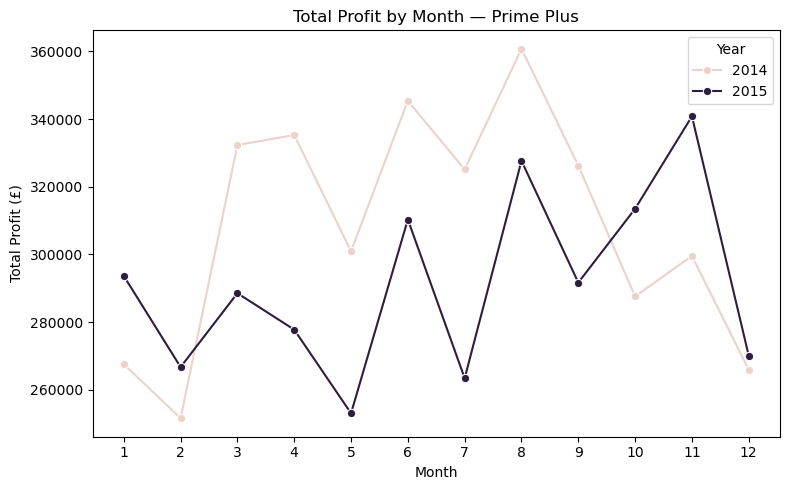

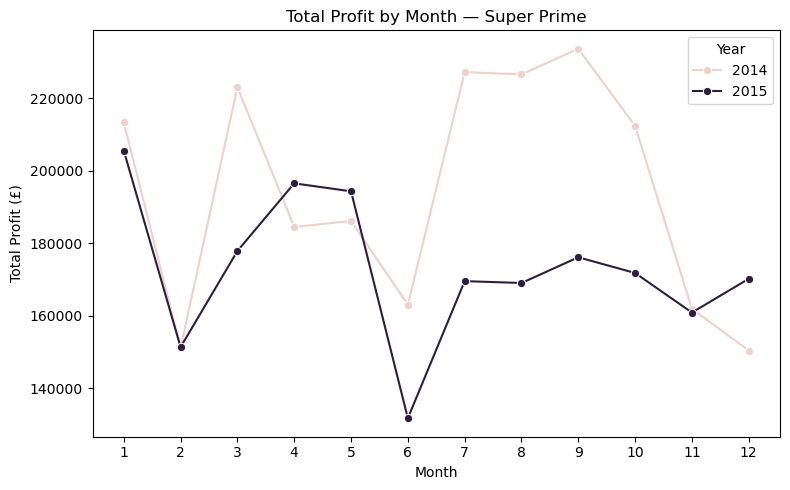

In [47]:
#Total Profit by Credit Band


credit_bands = [
    "Sub-Prime",
    "Near Prime",
    "Prime",
    "Prime Plus",
    "Super Prime"
]


for band in credit_bands:
    
    band_data = monthly_credit[monthly_credit["credit_band"] == band]

    plt.figure(figsize=(8,5))

    sns.lineplot(
        data=band_data,
        x="month",
        y="total_profit",
        hue="year",
        marker="o"
    )

    plt.title(f"Total Profit by Month — {band}")
    plt.xlabel("Month")
    plt.ylabel("Total Profit (£)")
    plt.xticks(range(1,13))
    plt.legend(title="Year")

    plt.tight_layout()
    plt.show()

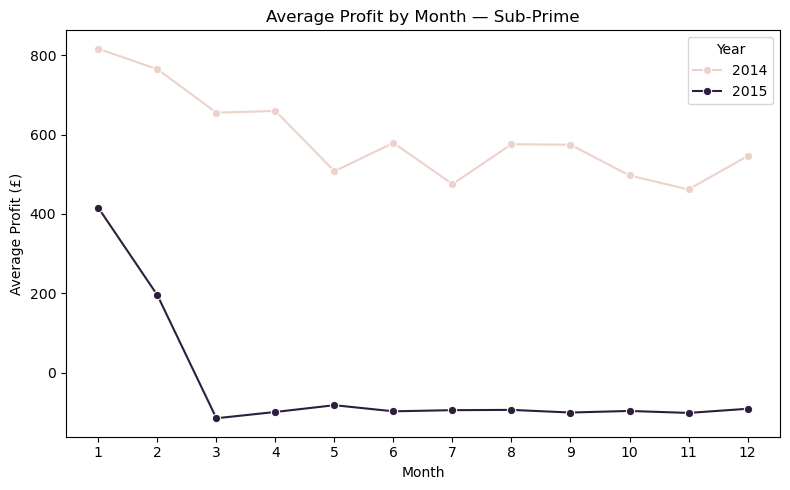

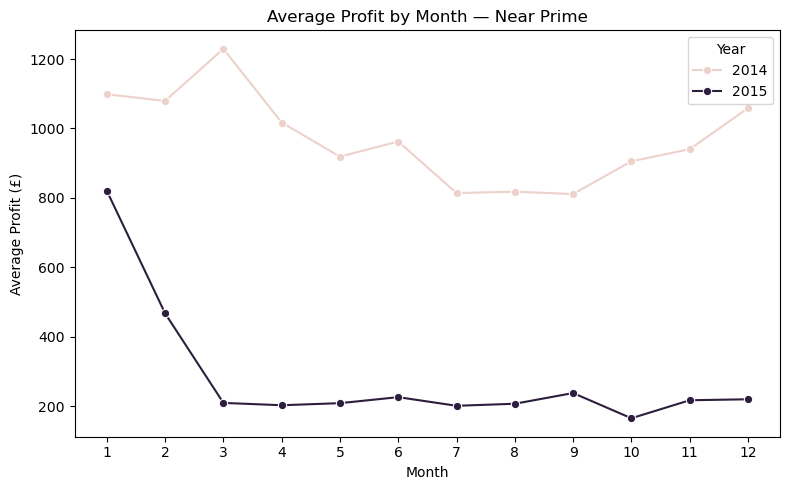

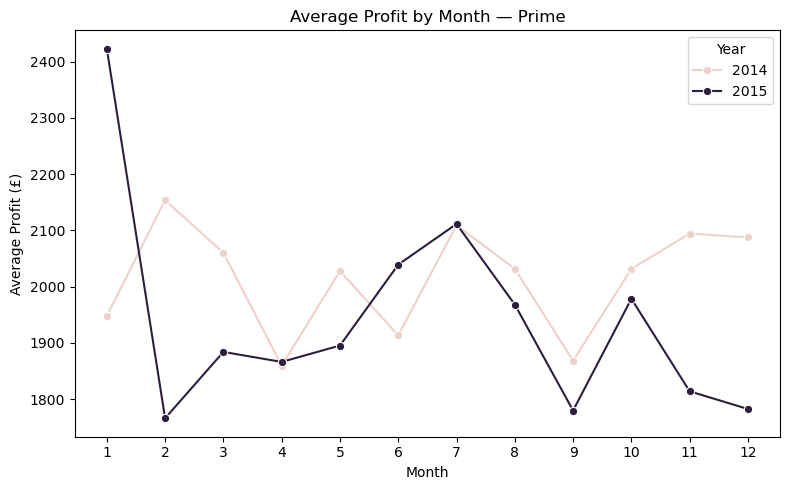

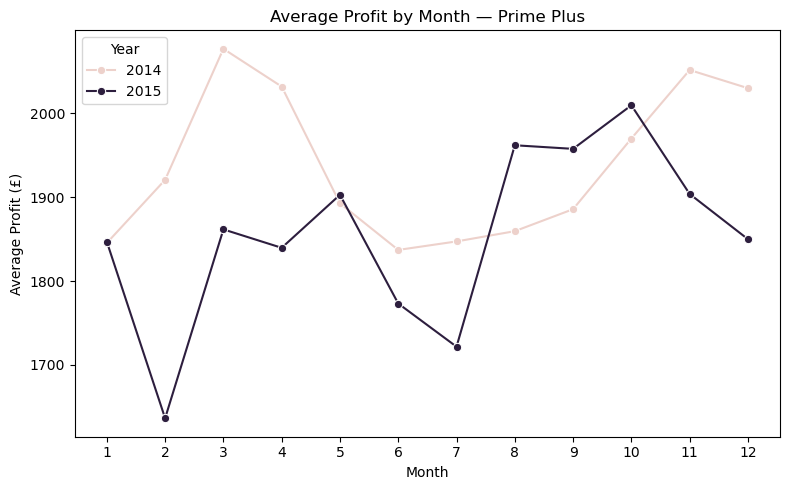

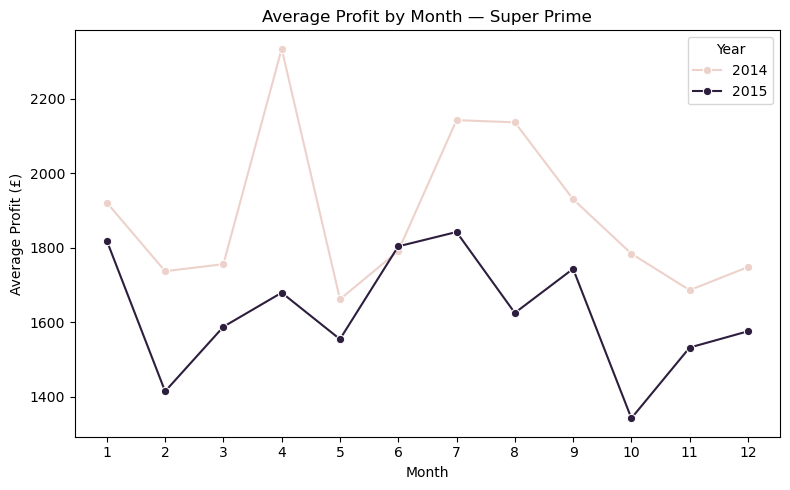

In [48]:
#Average Profit by Credit Band


credit_bands =[
    "Sub-Prime",
    "Near Prime",
    "Prime",
    "Prime Plus",
    "Super Prime"
]


for band in credit_bands:
    
    band_data = monthly_credit[monthly_credit["credit_band"] == band]

    plt.figure(figsize=(8,5))

    sns.lineplot(
        data=band_data,
        x="month",
        y="avg_profit",
        hue="year",
        marker="o"
    )

    plt.title(f"Average Profit by Month — {band}")
    plt.xlabel("Month")
    plt.ylabel("Average Profit (£)")
    plt.xticks(range(1,13))
    plt.legend(title="Year")

    plt.tight_layout()
    plt.show()
    #plt.savefig('C:/Users/Βασίλης/Desktop/Salary Finance/avg_profit_caps')

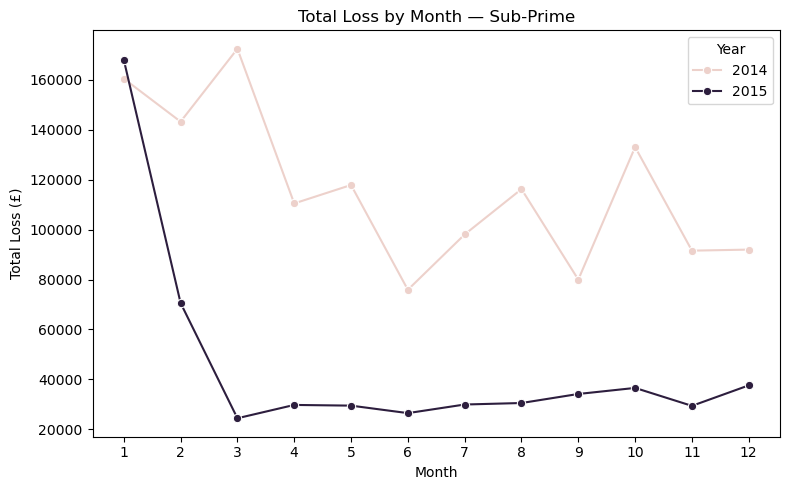

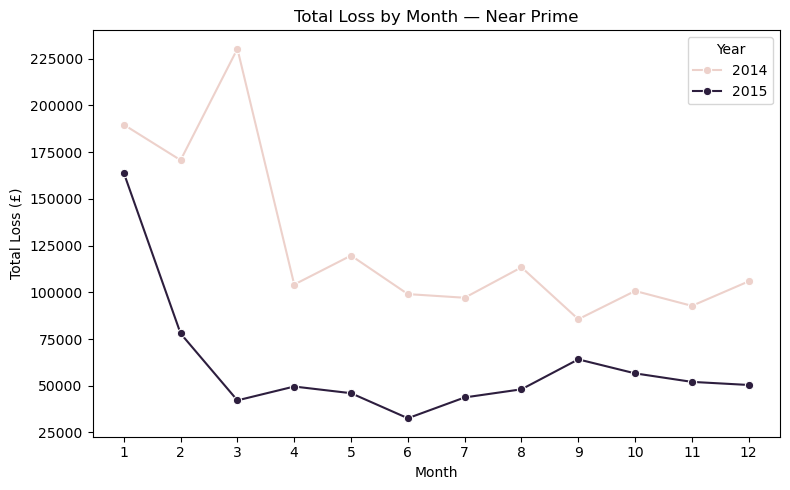

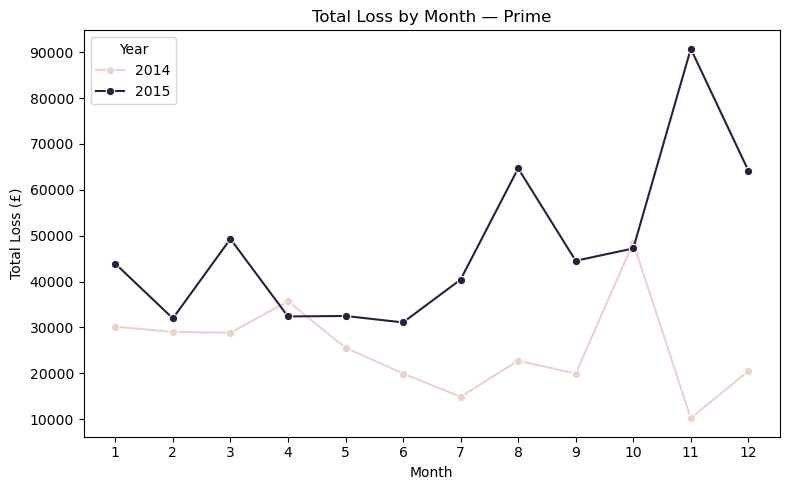

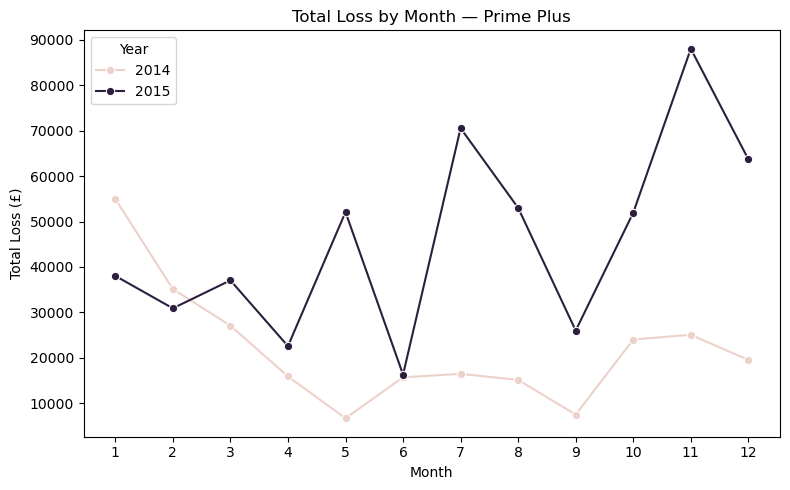

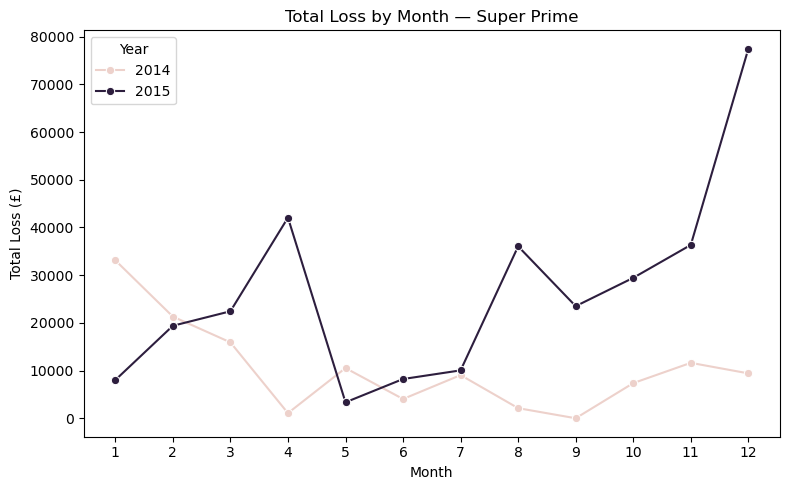

In [49]:
#Total Loss by Credit Band

credit_bands =[
    "Sub-Prime",
    "Near Prime",
    "Prime",
    "Prime Plus",
    "Super Prime"
]


for band in credit_bands:
    
    band_data = monthly_credit[monthly_credit["credit_band"] == band]

    plt.figure(figsize=(8,5))

    sns.lineplot(
        data=band_data,
        x="month",
        y="total_loss",
        hue="year",
        marker="o"
    )

    plt.title(f"Total Loss by Month — {band}")
    plt.xlabel("Month")
    plt.ylabel("Total Loss (£)")
    plt.xticks(range(1,13))
    plt.legend(title="Year")

    plt.tight_layout()
    plt.show()
    #plt.savefig('C:/Users/Βασίλης/Desktop/Salary Finance/total_loss_caps')

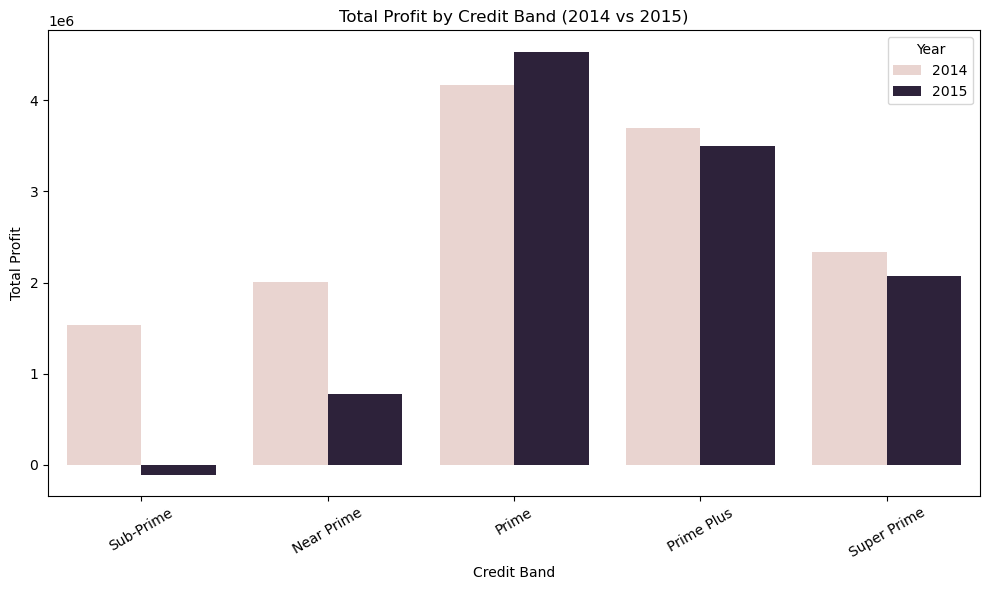

In [50]:
#Total Profit by Credit Band (2014 vs 2015)


plt.figure(figsize=(10,6))

band_order = [
    "Sub-Prime",
    "Near Prime",
    "Prime",
    "Prime Plus",
    "Super Prime"
]
sns.barplot(
    data=credit_policy,
    x="credit_band",
    y="total_profit",
    hue="year",
    order=band_order
)

plt.title("Total Profit by Credit Band (2014 vs 2015)")
plt.xlabel("Credit Band")
plt.ylabel("Total Profit")
plt.legend(title="Year")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()